# Import libraries

In [1]:
!pip install -q py_vncorenlp seqeval torchinfo

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.5 MB/s eta 0:00:00


In [2]:
import os
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

import py_vncorenlp
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
SEED = 42

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Download dataset

In [4]:
# "word" là bản đã được segment từ ví dụ "lịch sử" -> "lịch_sử"
dataset = load_dataset("phucdev/PhoNER_COVID19", "word")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

word/train-00000-of-00001.parquet:   0%|          | 0.00/366k [00:00<?, ?B/s]

word/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

word/test-00000-of-00001.parquet:   0%|          | 0.00/247k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [16]:
print(dataset['train'][1])

{'words': ['"', 'Số', 'bệnh_viện', 'có_thể', 'tiếp_nhận', 'bệnh_nhân', 'bị', 'sốt', 'cao', 'và', 'khó', 'thở', 'đang', 'giảm', 'dần', '"', ',', 'thông_cáo', 'có', 'đoạn', ',', 'cảnh_báo', 'những', 'bệnh_nhân', 'này', 'thay', 'vào', 'đó', 'được', 'chuyển', 'tới', 'các', 'phòng_khám', 'khẩn_cấp', ',', 'khiến', 'những', 'bệnh_nhân', 'mắc', 'bệnh', 'hiểm_nghèo', 'khác', 'không', 'có', 'cơ_hội', 'được', 'điều_trị', '.'], 'tags': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-SYMPTOM_AND_DISEASE', 'I-SYMPTOM_AND_DISEASE', 'O', 'B-SYMPTOM_AND_DISEASE', 'I-SYMPTOM_AND_DISEASE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


# Load tokenizer & rdrsegmenter

In [5]:
save_dir = os.path.abspath('/content/VnCoreNLP')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    py_vncorenlp.download_model(save_dir=save_dir)

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/content/VnCoreNLP')
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=True)

!cd /content/
# Cách dùng
# 1. Segment từ bằng rdrsegmenter
# ví dụ "Lịch sử" -> "Lịch_sử"
# segmented_list = rdrsegmenter.word_segment(text)
# segmented_text = " ".join(segmented_list)

# 2. Tokenize bằng PhoBERT Tokenizer
# inputs = tokenizer(
#     segmented_text,
#     padding='max_length',
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
print(tokenizer.vocab_size)

64000


# Preprocess data

In [18]:
# Bộ dataset cần ép về chuẩn NFC để tokenizers mới không bị lỗi
def preprocess(word_list):
    cleaned_words = [unicodedata.normalize('NFC', w) for w in word_list]
    return cleaned_words

clean_dataset = dataset.map(
    lambda x: {'words': preprocess(x['words'])},
    num_proc=2
)

# Measure dataset length

In [8]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["words"]]
    }

length_dataset = clean_dataset.map(
    get_length,
    batched=True,
    num_proc=2,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 26.36 | Max: 161 | p95: 50 | p99: 65

--- Statistics for validation ---
Mean: 28.14 | Max: 138 | p95: 54 | p99: 72

--- Statistics for test ---
Mean: 28.56 | Max: 162 | p95: 55 | p99: 72



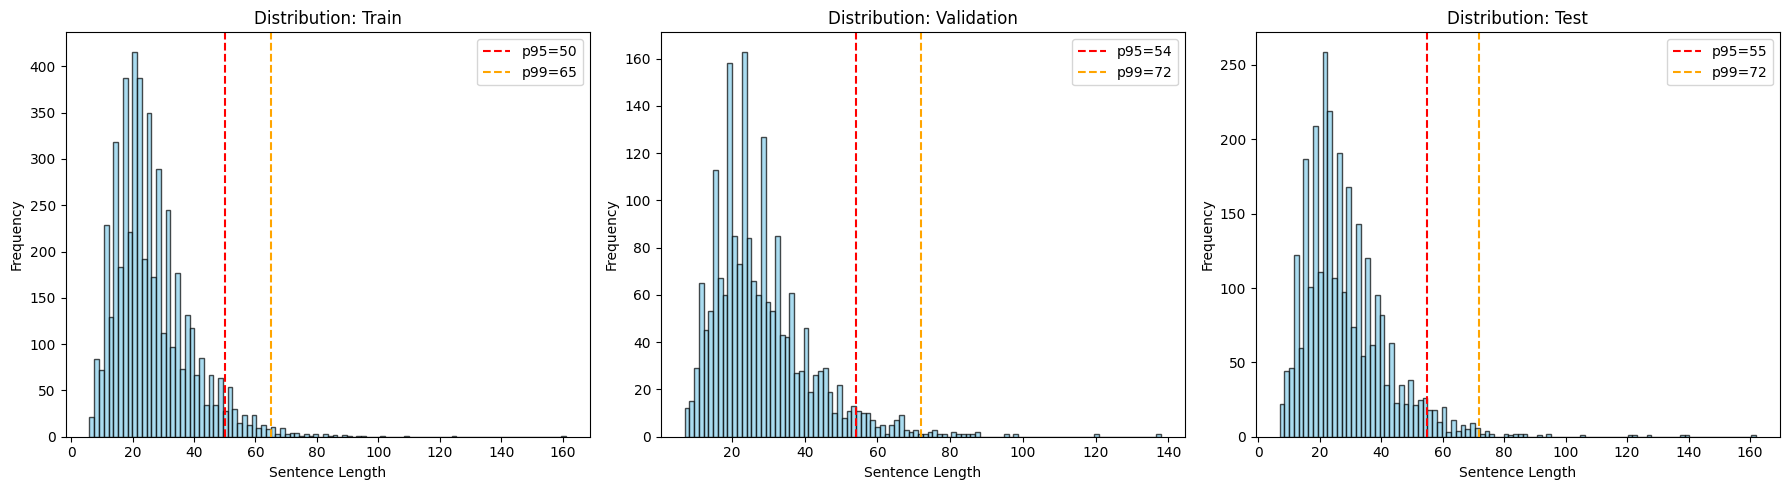

In [9]:
dataset_stats = {}
splits = ["train", "validation", "test"]

# Thiết lập figure cho plotting (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Tokenize dataset

In [10]:
unique_tags = set()
for tags in clean_dataset['train']['tags']:
    unique_tags.update(tags)

unique_tags = sorted(list(unique_tags))

label2idx = {tag: i for i, tag in enumerate(unique_tags)}
idx2label = {i: tag for i, tag in enumerate(unique_tags)}

IGNORE_INDEX = -100

print(f"Số lượng nhãn: {len(unique_tags)}")
print("IGNORE_INDEX:", IGNORE_INDEX)
print("label2idx:", label2idx)

Số lượng nhãn: 20
IGNORE_INDEX: -100
label2idx: {'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [19]:
# Do PhoBERT sử dụng kĩ thuật bpe do đó ta phải chỉnh lại label cho chính xác
def tokenize_and_align_labels(examples):
    all_input_ids = []
    all_labels = []
    all_attention_masks = []

    cls_token_id = tokenizer.cls_token_id   # PhoBERT: <s>
    sep_token_id = tokenizer.sep_token_id   # PhoBERT: </s>


    for words, tags in zip(examples["words"], examples["tags"]):

        body_input_ids = []
        body_label_ids = []

        for word, tag in zip(words, tags):
            word_piece_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(word_piece_ids) == 0:
                unk_id = tokenizer.unk_token_id
                word_piece_ids = [unk_id]

            body_input_ids.extend(word_piece_ids)

            body_label_ids.append(label2idx[tag])

            if len(word_piece_ids) > 1:
                body_label_ids.extend([IGNORE_INDEX] * (len(word_piece_ids) - 1))

        input_ids = [cls_token_id] + body_input_ids + [sep_token_id]
        labels = [IGNORE_INDEX] + body_label_ids + [IGNORE_INDEX]
        attention_mask = [1] * len(input_ids)

        all_input_ids.append(input_ids)
        all_labels.append(labels)
        all_attention_masks.append(attention_mask)

    return {
        "input_ids": all_input_ids,
        "labels": all_labels,
        "attention_mask": all_attention_masks,
    }

tokenized_dataset = clean_dataset.map(
    tokenize_and_align_labels,
    num_proc=2,
    batched=True,
    remove_columns=['words', 'tags']
)

In [20]:
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Utils

In [23]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=IGNORE_INDEX
)

In [24]:
# Sử dụng hàm này để tránh cho shape của train_loss, eval_loss lệch nhau dẫn tới
# vẽ biểu đồ không chính xác

def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
def labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [idx2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

In [26]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [27]:
def evaluate_model(trainer, eval_dataset, split_name='test', model_name='rnn'):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    accuracy = accuracy_score(true_labels, true_predictions)
    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(classification_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Model

#### Tổng quan về mô hình

``Input_ids``  
→ Embedding(padding_idx)  
→ Dropout  
→ pack_padded_sequence  
→ Bidirectional RNN  
→ pad_packed_sequence  
→ LayerNorm  
→ Dropout  
→ Linear Classification Head  
→ logits  
→ CrossEntropyLoss(ignore_index=-100)  

Trong phần này, mô hình Improved RNN được xây dựng nhằm giải quyết bài toán Named Entity Recognition (NER) trên dữ liệu tiếng Việt. Đây là bài toán gán nhãn cho từng token trong câu, trong đó mỗi token được phân loại vào một trong các nhãn BIO như B-AGE, B-LOCATION, B-SYMPTOM_AND_DISEASE, O, v.v.

+ Mô hình nhận đầu vào là chuỗi input_ids đã được tạo ra sau quá trình tokenization. Các token ID này trước tiên được đưa qua lớp Embedding để chuyển từ dạng chỉ số rời rạc sang vector liên tục có kích thước cố định. Trong mô hình, embedding layer được định nghĩa với tham số padding_idx, giúp vector của token padding không bị cập nhật trong quá trình huấn luyện. Điều này phù hợp vì token <pad> chỉ được thêm vào để đồng bộ độ dài các câu trong batch, không mang ý nghĩa ngôn ngữ.

+ Sau embedding, mô hình áp dụng Dropout nhằm giảm hiện tượng overfitting. Dropout ngẫu nhiên loại bỏ một phần thông tin trong quá trình huấn luyện, giúp mô hình không phụ thuộc quá mức vào một số đặc trưng cụ thể trong embedding.

+ Thành phần trung tâm của kiến trúc là lớp RNN hai chiều. Thay vì chỉ đọc chuỗi theo chiều từ trái sang phải như RNN truyền thống, mô hình sử dụng bidirectional=True, cho phép RNN đọc câu theo cả hai hướng: từ trái sang phải và từ phải sang trái. Nhờ đó, biểu diễn tại mỗi token có thể kết hợp cả ngữ cảnh phía trước và phía sau token đó. Đây là điểm quan trọng đối với bài toán NER, vì nhãn của một token thường phụ thuộc vào các từ xung quanh nó. Ví dụ, token ``45`` có thể được nhận diện là B-AGE khi xuất hiện trong ngữ cảnh 45 tuổi.

+ Để xử lý các câu có độ dài khác nhau, mô hình sử dụng attention_mask để tính độ dài thực tế của từng câu trong batch. Sau đó, dữ liệu được đưa qua pack_padded_sequence trước khi vào RNN. Kỹ thuật này giúp RNN chỉ xử lý các token thật và bỏ qua các token padding. Sau khi RNN xử lý xong, output được chuyển lại về tensor có kích thước ban đầu bằng pad_packed_sequence. Việc này giúp giảm nhiễu do padding và làm quá trình học hiệu quả hơn.

+ Đầu ra của RNN tại mỗi token là một vector ngữ cảnh. Do mô hình sử dụng RNN hai chiều, nếu hidden_dim = 256, output tại mỗi token sẽ có kích thước 256 * 2 = 512, bao gồm 256 chiều từ hướng forward và 256 chiều từ hướng backward. Vector này sau đó được đưa qua lớp Layer Normalization nhằm ổn định phân phối đặc trưng, giúp quá trình huấn luyện ổn định hơn. Tiếp theo, một lớp Dropout khác được sử dụng trước tầng phân loại để tiếp tục giảm overfitting.

+ Cuối cùng, mô hình sử dụng một lớp Linear Classification Head để ánh xạ vector ngữ cảnh của từng token sang không gian nhãn. Cụ thể, nếu bài toán có 20 nhãn, lớp Linear sẽ có dạng Linear(rnn_output_dim, 20). Kết quả đầu ra là logits có kích thước [batch_size, seq_len, num_labels], trong đó mỗi token có một vector điểm số tương ứng với toàn bộ các nhãn NER.

+ Hàm mất mát được tính bằng CrossEntropyLoss trên từng token. Trước khi tính loss, logits và labels được reshape về dạng phù hợp. Các vị trí có nhãn -100, bao gồm token đặc biệt như <s>, </s>, token padding và các subword phụ, sẽ bị bỏ qua thông qua tham số ignore_index. Điều này đảm bảo mô hình chỉ học từ các token có nhãn hợp lệ.

## Model definition

In [44]:
class ImprovedRNNModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        ignore_index,
        pad_token_id,
        num_layers=1,
        dropout=0.1,
        bidirectional=True,
        nonlinearity="tanh",
    ):
        super(ImprovedRNNModel, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_token_id
        )

        self.embedding_dropout = nn.Dropout(dropout)

        rnn_dropout = dropout if num_layers > 1 else 0.0

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout,
            bidirectional=bidirectional,
            nonlinearity=nonlinearity,
        )

        rnn_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.layer_norm = nn.LayerNorm(rnn_output_dim)
        self.output_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(rnn_output_dim, output_dim)

        self.ignore_index = ignore_index
        self.output_dim = output_dim
        self.pad_token_id = pad_token_id
        self.bidirectional = bidirectional

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # input_ids: [batch_size, seq_len]

        x = self.embedding(input_ids)
        # x: [batch_size, seq_len, embedding_dim]

        x = self.embedding_dropout(x)

        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).cpu()

            packed_x = nn.utils.rnn.pack_padded_sequence(
                x,
                lengths,
                batch_first=True,
                enforce_sorted=False
            )

            packed_out, _ = self.rnn(packed_x)

            x, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out,
                batch_first=True,
                total_length=input_ids.size(1)
            )
        else:
            x, _ = self.rnn(x)

        # Nếu bidirectional=True:
        # x: [batch_size, seq_len, hidden_dim * 2]

        x = self.layer_norm(x)
        x = self.output_dropout(x)

        logits = self.fc(x)
        # logits: [batch_size, seq_len, output_dim]

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, self.output_dim),
                labels.reshape(-1),
                ignore_index=self.ignore_index
            )

        return {
            "loss": loss,
            "logits": logits
        }

In [47]:
rnn_model = ImprovedRNNModel(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=256,
    hidden_dim=256,
    output_dim=len(unique_tags),
    ignore_index=IGNORE_INDEX,
    pad_token_id=tokenizer.pad_token_id,
    num_layers=1,
    dropout=0.1,
    bidirectional=True,
    nonlinearity="tanh",
)


In [48]:
summary(rnn_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
ImprovedRNNModel                         [1, 10, 20]               --
├─Embedding: 1-1                         [1, 10, 256]              16,384,000
├─Dropout: 1-2                           [1, 10, 256]              --
├─RNN: 1-3                               [1, 10, 512]              263,168
├─LayerNorm: 1-4                         [1, 10, 512]              1,024
├─Dropout: 1-5                           [1, 10, 512]              --
├─Linear: 1-6                            [1, 10, 20]               10,260
Total params: 16,658,452
Trainable params: 16,658,452
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 19.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.10
Params size (MB): 66.63
Estimated Total Size (MB): 66.74

### Training

## RNN

### Training

In [50]:
training_args = TrainingArguments(
    output_dir="/content/improved_rnn_ner",

    num_train_epochs=100,
    learning_rate=5e-4,
    weight_decay=0.01,
    max_grad_norm=1.0,
    warmup_steps=50,

    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,

    logging_strategy="epoch",
    logging_first_step=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
)

In [51]:
trainer = Trainer(
    model=rnn_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [52]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,2.800235,2.008423,0.034063
2,1.192358,0.790508,0.177115
3,0.535372,0.478877,0.531063
4,0.320173,0.362427,0.646273
5,0.239897,0.308812,0.698745
6,0.195547,0.261472,0.738197
7,0.165695,0.231017,0.766387
8,0.145651,0.217718,0.777267
9,0.128279,0.215666,0.783563
10,0.117037,0.200650,0.795572


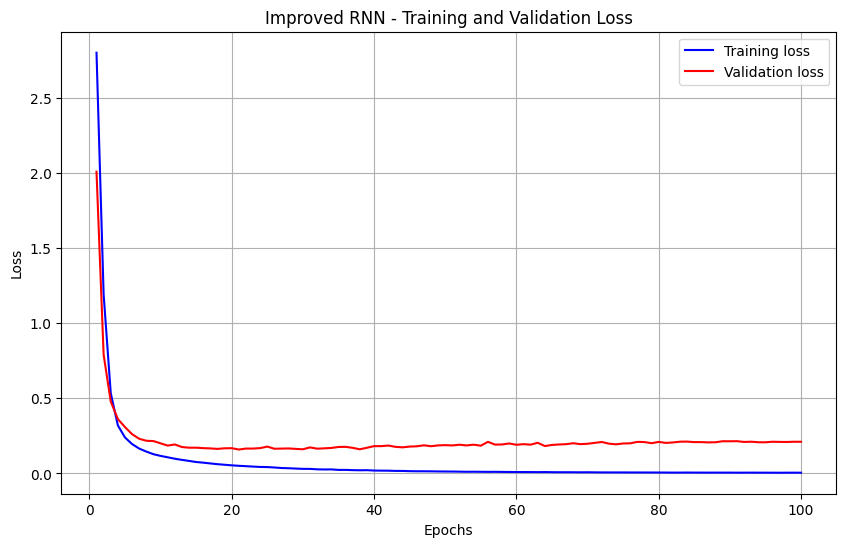

In [53]:
plot_loss_curves(
    trainer.state.log_history,
    title="RNN - Training and Validation Loss"
)

In [56]:
test_result = evaluate_model(
    trainer=trainer,
    eval_dataset=tokenized_dataset["test"],
    split_name="test",
    model_name="Improved RNN"
)

test_result

Evaluation on test set using Improved RNN
Classification Report:
                     precision    recall  f1-score   support

                AGE       0.94      0.95      0.94       582
               DATE       0.94      0.96      0.95      1654
             GENDER       0.93      0.93      0.93       462
                JOB       0.60      0.45      0.52       173
           LOCATION       0.83      0.85      0.84      4441
               NAME       0.92      0.75      0.82       318
       ORGANIZATION       0.71      0.74      0.72       771
         PATIENT_ID       0.95      0.95      0.95      2005
SYMPTOM_AND_DISEASE       0.79      0.72      0.75      1136
     TRANSPORTATION       0.90      0.84      0.87       193

          micro avg       0.87      0.86      0.86     11735
          macro avg       0.85      0.81      0.83     11735
       weighted avg       0.87      0.86      0.86     11735

Accuracy: 0.9560
Precision: 0.8663
Recall: 0.8613
F1 Score: 0.8638


{'accuracy': 0.9559630243469736,
 'precision': np.float64(0.8662895345847261),
 'recall': np.float64(0.8612697060076694),
 'f1': np.float64(0.8637723271515254)}

### Evaluate

In [57]:
rnn_result = evaluate_model(trainer, test_dataset, split_name='test', model_name='RNN')

Evaluation on test set using RNN
Classification Report:
                     precision    recall  f1-score   support

                AGE       0.94      0.95      0.94       582
               DATE       0.94      0.96      0.95      1654
             GENDER       0.93      0.93      0.93       462
                JOB       0.60      0.45      0.52       173
           LOCATION       0.83      0.85      0.84      4441
               NAME       0.92      0.75      0.82       318
       ORGANIZATION       0.71      0.74      0.72       771
         PATIENT_ID       0.95      0.95      0.95      2005
SYMPTOM_AND_DISEASE       0.79      0.72      0.75      1136
     TRANSPORTATION       0.90      0.84      0.87       193

          micro avg       0.87      0.86      0.86     11735
          macro avg       0.85      0.81      0.83     11735
       weighted avg       0.87      0.86      0.86     11735

Accuracy: 0.9560
Precision: 0.8663
Recall: 0.8613
F1 Score: 0.8638


### Save model weight

In [59]:
import os
import json
from safetensors.torch import save_file

In [61]:
def save_loss_curve(history, save_path, title="Training and Validation Loss"):
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get("epoch")
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        # Chỉ lấy log ở cuối epoch đầy đủ: 1.0, 2.0, 3.0, ...
        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        # Training loss thường có key "loss"
        if "loss" in log and "eval_loss" not in log:
            train_epoch_loss[epoch_int] = log["loss"]

        # Validation loss có key "eval_loss"
        if "eval_loss" in log:
            eval_epoch_loss[epoch_int] = log["eval_loss"]

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))

    if not epochs:
        raise ValueError("No aligned full-epoch train/eval loss points were found.")

    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, "b", label="Training loss")
    plt.plot(epochs, eval_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Lưu file ảnh
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [63]:
model_name = "improved_rnn"
save_dir = f"/content/{model_name}"

os.makedirs(save_dir, exist_ok=True)


# 1. Lưu model weight thành model.safetensors
model_state_dict = trainer.model.state_dict()

save_file(
    model_state_dict,
    os.path.join(save_dir, "model.safetensors")
)

In [64]:
# 2. Lưu model_config.json

model_config = {
    "model_name": "ImprovedRNNModel",

    "vocab_size": int(tokenizer.vocab_size),
    "embedding_dim": 256,
    "hidden_dim": 256,
    "output_dim": int(len(unique_tags)),

    "ignore_index": int(IGNORE_INDEX),
    "pad_token_id": int(tokenizer.pad_token_id),

    "num_layers": 1,
    "dropout": 0.1,
    "bidirectional": True,
    "nonlinearity": "tanh",

    "num_labels": int(len(unique_tags)),
    "label2idx": label2idx,
    "idx2label": {str(k): v for k, v in idx2label.items()}
}

with open(os.path.join(save_dir, "model_config.json"), "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=4)


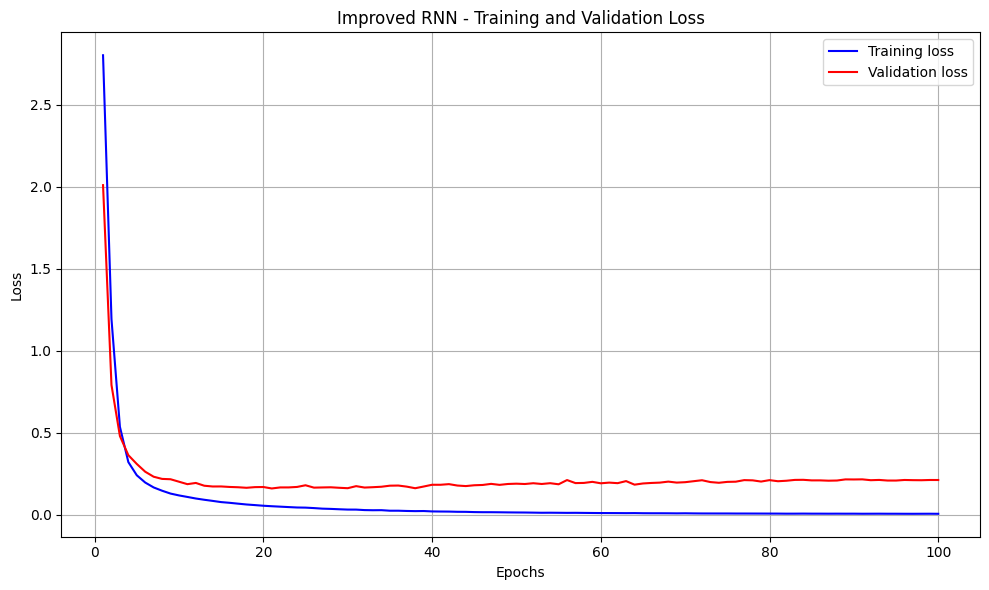

In [65]:
# 3. Lưu loss_curve.png

save_loss_curve(
    trainer.state.log_history,
    os.path.join(save_dir, "loss_curve.png"),
    title="Improved RNN - Training and Validation Loss"
)


In [66]:
# 4. Lưu result.json

# test_result lấy từ hàm evaluate_model(...)

with open(os.path.join(save_dir, "result.json"), "w", encoding="utf-8") as f:
    json.dump(test_result, f, ensure_ascii=False, indent=4)



In [67]:
# 5. Kiểm tra file đã lưu

print(f"Saved files to: {save_dir}")
print(os.listdir(save_dir))

Saved files to: /content/improved_rnn
['result.json', 'model_config.json', 'loss_curve.png', 'model.safetensors']


#### Tải folder về máy

In [68]:
!zip -r /content/improved_rnn.zip /content/improved_rnn

from google.colab import files
files.download("/content/improved_rnn.zip")

  adding: content/improved_rnn/ (stored 0%)
  adding: content/improved_rnn/result.json (deflated 27%)
  adding: content/improved_rnn/model_config.json (deflated 66%)
  adding: content/improved_rnn/loss_curve.png (deflated 22%)
  adding: content/improved_rnn/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>